# 🚦 Flipkart Gridlock 2.0 — LightGBM Pipeline
**Goal:** Predict traffic `demand` (0–1 scale) | **Metric:** `max(0, 100 × R²)`

### Key data facts (from EDA)
- **Train:** Day 48 (all 96 slots) + Day 49 (slots 0:0 → 2:0, i.e. 9 slots)
- **Test:**  Day 49 (slots 2:15 → 13:45, i.e. 47 slots) — continues where train ends
- **Timestamps:** every 15 min → `H:MM` format, 96 slots/day
- **Geohashes:** 1249 in train, 1190 in test, 1180 overlap, 10 unseen
- **Demand:** float in [0, 1], heavily right-skewed (skew=3.73)
- **Missings:** RoadType (600), Temperature (2495), Weather (797) in train

## 📦 1. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder

# !pip install pygeohash -q
import pygeohash as pgh

pd.set_option('display.max_columns', 50)
SEED = 42
np.random.seed(SEED)

# ── Paths (change for Kaggle) ────────────────────────────────
TRAIN_PATH = '/kaggle/input/datasets/deetyam/traffic-data/train.csv'
TEST_PATH  = '/kaggle/input/datasets/deetyam/traffic-data/test.csv'
SUB_PATH   = '/kaggle/input/datasets/deetyam/sample-submission/sample_submission.csv'

print('✅ Libraries loaded')

✅ Libraries loaded


## 📂 2. Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sub   = pd.read_csv(SUB_PATH)

print(f'Train : {train.shape}')   # (77299, 11)
print(f'Test  : {test.shape}')    # (41778, 10)
print(f'Sub   : {sub.shape}')     # (41778,  2)
train.head(3)

Train : (77299, 11)
Test  : (41778, 10)
Sub   : (5, 2)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny


## 🔍 3. Quick EDA

In [3]:
print('=== MISSING VALUES (train) ===')
print(train.isnull().sum())
print('\n=== DEMAND STATS ===')
print(train['demand'].describe())
print(f'Skew: {train["demand"].skew():.3f}')

=== MISSING VALUES (train) ===
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

=== DEMAND STATS ===
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Skew: 3.729


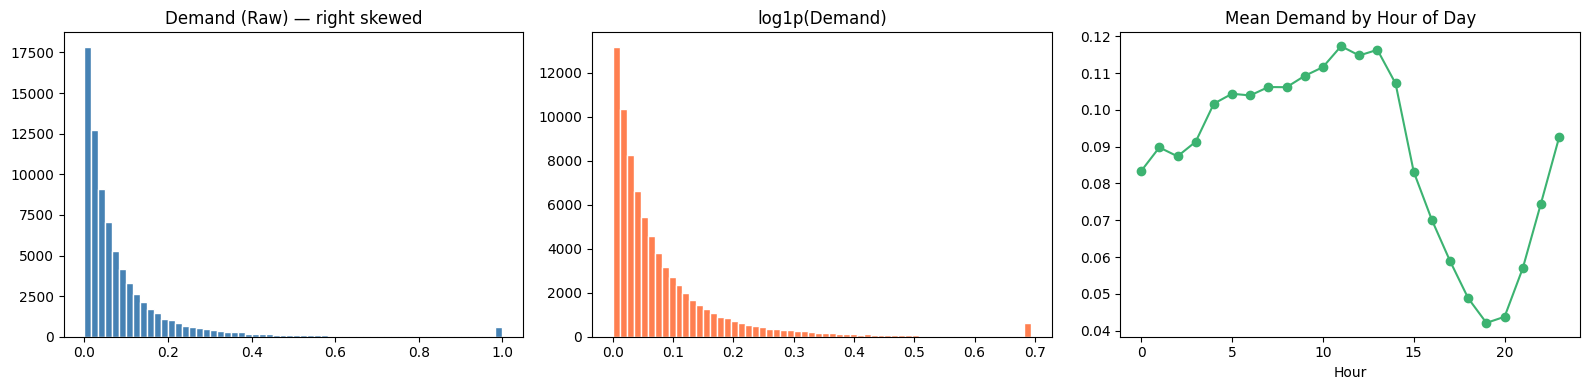

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Demand distribution
axes[0].hist(train['demand'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Demand (Raw) — right skewed')

axes[1].hist(np.log1p(train['demand']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('log1p(Demand)')

# Mean demand by hour
def parse_ts(ts):
    h, m = str(ts).split(':')
    return int(h) * 60 + int(m)

train['ts_min'] = train['timestamp'].apply(parse_ts)
train['hour']   = train['ts_min'] // 60

hourly = train.groupby('hour')['demand'].mean()
axes[2].plot(hourly.index, hourly.values, marker='o', color='mediumseagreen')
axes[2].set_title('Mean Demand by Hour of Day')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.show()

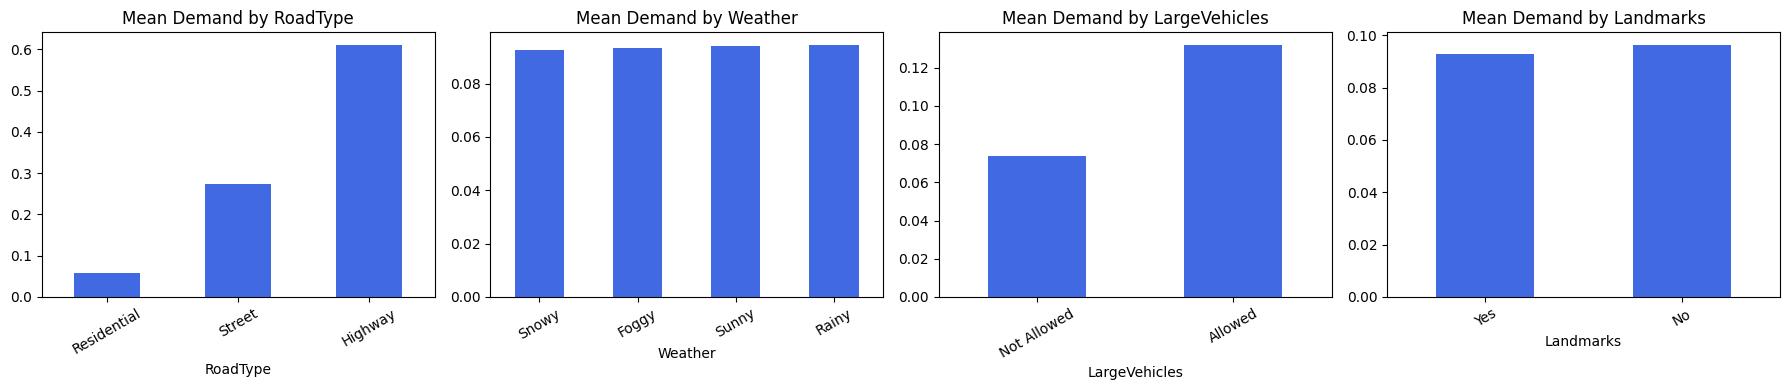

In [5]:
# Demand by categorical features
cat_cols = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    train.groupby(col)['demand'].mean().sort_values().plot(kind='bar', ax=ax, color='royalblue')
    ax.set_title(f'Mean Demand by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## ⚙️ 4. Feature Engineering

In [6]:
# ── Helper: parse 'H:MM' timestamp ──────────────────────────
def parse_ts(ts):
    """'14:30' -> 870 minutes from midnight"""
    h, m = str(ts).split(':')
    return int(h) * 60 + int(m)


# ── Helper: decode geohash -> lat, lon ──────────────────────
def decode_geohash_safe(gh):
    try:
        lat, lon = pgh.decode(gh)
        return float(lat), float(lon)
    except:
        return np.nan, np.nan


def build_features(df):
    df = df.copy()

    # ── 4.1  Timestamp decomposition ────────────────────────
    df['ts_min']  = df['timestamp'].apply(parse_ts)
    df['hour']    = df['ts_min'] // 60
    df['minute']  = df['ts_min'] % 60
    df['slot_id'] = df['ts_min'] // 15   # 0..95 — which of the 96 daily slots

    # Cyclical encoding — tells model 23:45 and 0:00 are close
    df['hour_sin']   = np.sin(2 * np.pi * df['hour']    / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour']    / 24)
    df['minute_sin'] = np.sin(2 * np.pi * df['minute']  / 60)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute']  / 60)
    df['slot_sin']   = np.sin(2 * np.pi * df['slot_id'] / 96)
    df['slot_cos']   = np.cos(2 * np.pi * df['slot_id'] / 96)

    # ── 4.2  Peak flags ─────────────────────────────────────
    df['is_morning_peak'] = df['hour'].isin([7, 8, 9]).astype(int)
    df['is_evening_peak'] = df['hour'].isin([17, 18, 19, 20]).astype(int)
    df['is_peak']         = (df['is_morning_peak'] | df['is_evening_peak']).astype(int)
    df['is_night']        = df['hour'].isin([22, 23, 0, 1, 2, 3, 4]).astype(int)
    df['is_early_morning']= df['hour'].isin([5, 6]).astype(int)

    # ── 4.3  Day feature ────────────────────────────────────
    # Day 48/49 → encode as-is; also relative slot across both days
    df['day_norm'] = df['day'] - df['day'].min()  # 0 or 1
    # Global time index: minutes since start of day 48
    df['global_ts'] = df['day_norm'] * 1440 + df['ts_min']

    # ── 4.4  Geohash decode ─────────────────────────────────
    geo_coords = df['geohash'].apply(decode_geohash_safe)
    df['lat'] = geo_coords.apply(lambda x: x[0])
    df['lon'] = geo_coords.apply(lambda x: x[1])
    df['geohash_len'] = df['geohash'].apply(len)

    # ── 4.5  Encode categoricals ─────────────────────────────
    # LargeVehicles: binary
    df['large_vehicles_bin'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    # Landmarks: binary
    df['landmarks_bin'] = (df['Landmarks'] == 'Yes').astype(int)

    # RoadType ordinal (higher = more lanes expected)
    road_map = {'Residential': 0, 'Street': 1, 'Highway': 2}
    df['roadtype_ord'] = df['RoadType'].map(road_map).fillna(-1).astype(int)

    # Weather ordinal (severity)
    weather_map = {'Sunny': 0, 'Foggy': 1, 'Rainy': 2, 'Snowy': 3}
    df['weather_ord'] = df['Weather'].map(weather_map).fillna(-1).astype(int)

    # ── 4.6  Interaction features ────────────────────────────
    df['lanes_x_hour']     = df['NumberofLanes'] * df['hour']
    df['lanes_x_peak']     = df['NumberofLanes'] * df['is_peak']
    df['weather_x_hour']   = df['weather_ord']   * df['hour']
    df['road_x_lanes']     = df['roadtype_ord']  * df['NumberofLanes']
    df['temp_x_hour']      = df['Temperature']   * df['hour']
    df['temp_x_peak']      = df['Temperature']   * df['is_peak']

    return df


train = build_features(train)
test  = build_features(test)
print(f'✅ Basic features done | Train: {train.shape}')

✅ Basic features done | Train: (77299, 41)


In [7]:
# ── 4.7  Geohash aggregate features (from TRAIN only!) ──────
# These are the most powerful features — they tell the model
# 'what kind of location is this historically'

# Overall demand stats per geohash
geo_stats = (
    train.groupby('geohash')['demand']
    .agg(geo_mean='mean', geo_std='std', geo_median='median',
         geo_max='max', geo_min='min', geo_q75='quantile',
         geo_count='count')
    .reset_index()
)
# quantile default is 0.5; fix to q75
geo_stats['geo_q75'] = train.groupby('geohash')['demand'].quantile(0.75).values

# Demand stats per geohash × hour (captures daily rhythm per location)
geo_hour = (
    train.groupby(['geohash', 'hour'])['demand']
    .agg(geo_hour_mean='mean', geo_hour_std='std')
    .reset_index()
)

# Demand stats per geohash × slot_id (even finer — per 15-min slot)
geo_slot = (
    train.groupby(['geohash', 'slot_id'])['demand']
    .agg(geo_slot_mean='mean', geo_slot_std='std')
    .reset_index()
)

# Global hour mean (captures city-wide pattern at that time)
hour_global = (
    train.groupby('hour')['demand']
    .agg(hour_global_mean='mean', hour_global_std='std')
    .reset_index()
)

# RoadType × hour mean
road_hour = (
    train.groupby(['roadtype_ord', 'hour'])['demand']
    .agg(road_hour_mean='mean')
    .reset_index()
)

def apply_aggs(df):
    df = df.merge(geo_stats,    on='geohash',              how='left')
    df = df.merge(geo_hour,     on=['geohash', 'hour'],    how='left')
    df = df.merge(geo_slot,     on=['geohash', 'slot_id'], how='left')
    df = df.merge(hour_global,  on='hour',                 how='left')
    df = df.merge(road_hour,    on=['roadtype_ord', 'hour'], how='left')
    return df

train = apply_aggs(train)
test  = apply_aggs(test)
print(f'✅ Aggregate features done | Train: {train.shape}')

✅ Aggregate features done | Train: (77299, 55)


In [8]:
# ── 4.8  Lag features — the most critical ones ──────────────
#
# KEY INSIGHT: Test is Day49 slots 2:15–13:45
#              Train has Day49 slots 0:00–2:00
#              So we CAN build lags from the last known train values!
#
# Strategy: for each geohash, sort by global_ts and shift

train = train.sort_values(['geohash', 'global_ts']).reset_index(drop=True)

for lag in [1, 2, 3, 4, 8]:    # 1=15min ago, 4=1hr ago, 8=2hrs ago
    train[f'lag_{lag}'] = train.groupby('geohash')['demand'].shift(lag)

# Rolling stats over last 4 and 8 slots
for window in [4, 8]:
    rolled = train.groupby('geohash')['demand'].shift(1).rolling(window)
    train[f'roll_mean_{window}'] = rolled.mean().reset_index(level=0, drop=True)
    train[f'roll_std_{window}']  = rolled.std().reset_index(level=0, drop=True)
    train[f'roll_max_{window}']  = rolled.max().reset_index(level=0, drop=True)

# ── For TEST: get the last N known demand values from train ──
# The last row of each geohash in train = lag_1 for first test row
# We build a lookup: geohash -> [last 8 demand values]

last_n = 8
last_demands = (
    train.sort_values(['geohash', 'global_ts'])
         .groupby('geohash')['demand']
         .apply(lambda x: x.values[-last_n:])   # last 8 values
)

def get_lag_for_test(geohash, lag):
    """lag=1 -> most recent train value for that geohash"""
    if geohash not in last_demands.index:
        return np.nan
    arr = last_demands[geohash]
    idx = len(arr) - lag
    return arr[idx] if idx >= 0 else np.nan

for lag in [1, 2, 3, 4, 8]:
    test[f'lag_{lag}'] = test['geohash'].apply(lambda g: get_lag_for_test(g, lag))

# Rolling for test (approximate from available lags)
lag_cols_4 = [f'lag_{i}' for i in [1, 2, 3, 4]]
test['roll_mean_4'] = test[lag_cols_4].mean(axis=1)
test['roll_std_4']  = test[lag_cols_4].std(axis=1)
test['roll_max_4']  = test[lag_cols_4].max(axis=1)

lag_cols_8 = [f'lag_{i}' for i in [1, 2, 3, 4, 8]]
test['roll_mean_8'] = test[lag_cols_8].mean(axis=1)
test['roll_std_8']  = test[lag_cols_8].std(axis=1)
test['roll_max_8']  = test[lag_cols_8].max(axis=1)

lag_feat_cols = [f'lag_{l}' for l in [1,2,3,4,8]] + \
    [f'roll_mean_{w}' for w in [4,8]] + \
    [f'roll_std_{w}'  for w in [4,8]] + \
    [f'roll_max_{w}'  for w in [4,8]]

print(f'✅ Lag features done')
print(f'   Train lag_1 non-null: {train["lag_1"].notna().sum()} / {len(train)}')
print(f'   Test  lag_1 non-null: {test["lag_1"].notna().sum()} / {len(test)}')

✅ Lag features done
   Train lag_1 non-null: 76050 / 77299
   Test  lag_1 non-null: 41753 / 41778


In [9]:
# ── 4.9  Encode geohash as integer ID ───────────────────────
le_geo = LabelEncoder()
all_geos = pd.concat([train['geohash'], test['geohash']], axis=0).astype(str)
le_geo.fit(all_geos)
train['geohash_id'] = le_geo.transform(train['geohash'].astype(str))
test['geohash_id']  = le_geo.transform(test['geohash'].astype(str))
print('✅ Geohash encoded')

✅ Geohash encoded


## 🎯 5. Define Feature Set & Target

In [10]:
# Columns to drop (leakage, ids, raw strings)
DROP = ['Index', 'demand', 'geohash', 'timestamp', 'RoadType',
        'LargeVehicles', 'Landmarks', 'Weather']

FEATURES = [c for c in train.columns if c not in DROP]
TARGET   = 'demand'

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]

print(f'Total features : {len(FEATURES)}')
print('Features:', FEATURES)

Total features : 59
Features: ['day', 'NumberofLanes', 'Temperature', 'ts_min', 'hour', 'minute', 'slot_id', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'slot_sin', 'slot_cos', 'is_morning_peak', 'is_evening_peak', 'is_peak', 'is_night', 'is_early_morning', 'day_norm', 'global_ts', 'lat', 'lon', 'geohash_len', 'large_vehicles_bin', 'landmarks_bin', 'roadtype_ord', 'weather_ord', 'lanes_x_hour', 'lanes_x_peak', 'weather_x_hour', 'road_x_lanes', 'temp_x_hour', 'temp_x_peak', 'geo_mean', 'geo_std', 'geo_median', 'geo_max', 'geo_min', 'geo_q75', 'geo_count', 'geo_hour_mean', 'geo_hour_std', 'geo_slot_mean', 'geo_slot_std', 'hour_global_mean', 'hour_global_std', 'road_hour_mean', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'roll_mean_4', 'roll_std_4', 'roll_max_4', 'roll_mean_8', 'roll_std_8', 'roll_max_8', 'geohash_id']


## 🏋️ 6. LightGBM — 5-Fold Cross Validation

In [11]:
lgb_params = {
    # Task
    'objective'         : 'regression',
    'metric'            : 'rmse',
    'boosting_type'     : 'gbdt',

    # Tree structure
    'num_leaves'        : 127,       # tune up/down based on overfit
    'max_depth'         : -1,
    'min_child_samples' : 20,

    # Learning
    'learning_rate'     : 0.05,
    'n_estimators'      : 5000,      # high; early stopping handles it

    # Regularisation
    'reg_alpha'         : 0.1,       # L1
    'reg_lambda'        : 0.1,       # L2
    'min_gain_to_split' : 0.0,

    # Subsampling
    'subsample'         : 0.8,
    'subsample_freq'    : 1,
    'colsample_bytree'  : 0.8,

    # Misc
    'random_state'      : SEED,
    'n_jobs'            : -1,
    'verbose'           : -1,
}

N_FOLDS     = 5
kf          = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds   = np.zeros(len(train))
test_preds  = np.zeros(len(test))
fold_scores = []
models      = []

print(f'Starting {N_FOLDS}-Fold CV...')
print('=' * 55)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=500),
        ]
    )

    val_pred             = np.clip(model.predict(X_val), 0, 1)
    oof_preds[val_idx]   = val_pred
    test_preds          += np.clip(model.predict(X_test), 0, 1) / N_FOLDS
    models.append(model)

    score = max(0, 100 * r2_score(y_val, val_pred))
    fold_scores.append(score)
    print(f'Fold {fold+1}/{N_FOLDS} | Score={score:.4f} | Best iter={model.best_iteration_}')

print('=' * 55)
oof_score = max(0, 100 * r2_score(y, oof_preds))
print(f'OOF Score : {oof_score:.4f}')
print(f'Fold mean : {np.mean(fold_scores):.2f} ± {np.std(fold_scores):.2f}')

Starting 5-Fold CV...
Fold 1/5 | Score=99.6684 | Best iter=396
[500]	valid_0's rmse: 0.00920493
Fold 2/5 | Score=99.5882 | Best iter=582
[500]	valid_0's rmse: 0.00806429
Fold 3/5 | Score=99.6704 | Best iter=651
Fold 4/5 | Score=99.6255 | Best iter=239
[500]	valid_0's rmse: 0.00774771
Fold 5/5 | Score=99.7076 | Best iter=536
OOF Score : 99.6517
Fold mean : 99.65 ± 0.04


## 📊 7. Diagnostics

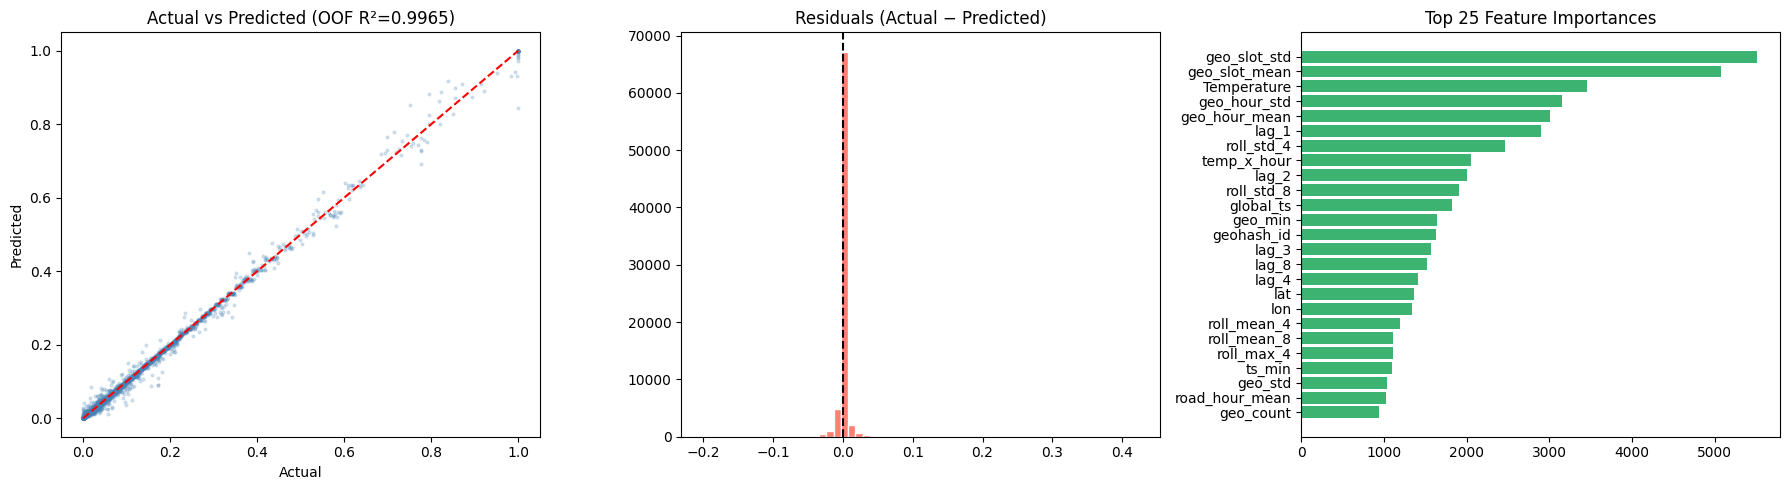

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted
sample = np.random.choice(len(y), size=min(5000, len(y)), replace=False)
axes[0].scatter(y.values[sample], oof_preds[sample], alpha=0.2, s=4, color='steelblue')
lims = [0, 1]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted (OOF R²={oof_score/100:.4f})')

# Residuals
residuals = y.values - oof_preds
axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Residuals (Actual − Predicted)')

# Feature importance (avg across folds)
imp = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=True).tail(25)

axes[2].barh(imp['feature'], imp['importance'], color='mediumseagreen')
axes[2].set_title('Top 25 Feature Importances')

plt.tight_layout()
plt.show()

## 🔧 8. Optuna Hyperparameter Tuning (run after baseline)

In [13]:
# !pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'boosting_type'     : 'gbdt',
        'n_estimators'      : 3000,
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'learning_rate'     : trial.suggest_float('learning_rate',      0.01,  0.1,  log=True),
        'num_leaves'        : trial.suggest_int(  'num_leaves',         31,    255),
        'max_depth'         : trial.suggest_int(  'max_depth',          3,     12),
        'min_child_samples' : trial.suggest_int(  'min_child_samples',  5,     100),
        'subsample'         : trial.suggest_float('subsample',          0.5,   1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree',   0.5,   1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha',          1e-8,  10,   log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda',         1e-8,  10,   log=True),
        'min_gain_to_split' : trial.suggest_float('min_gain_to_split',  0,     1),
    }

    kf3 = KFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in kf3.split(X, y):
        m = lgb.LGBMRegressor(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        pred = np.clip(m.predict(X.iloc[val_idx]), 0, 1)
        scores.append(max(0, 100 * r2_score(y.iloc[val_idx], pred)))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Best Score  : {study.best_value:.4f}')
print(f'Best Params : {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best Score  : 99.5358
Best Params : {'learning_rate': 0.010150937241864066, 'num_leaves': 156, 'max_depth': 8, 'min_child_samples': 43, 'subsample': 0.5054817651388256, 'colsample_bytree': 0.7065533918468363, 'reg_alpha': 0.0060301213142186835, 'reg_lambda': 9.379275047445884e-08, 'min_gain_to_split': 0.0008851625239412152}


In [14]:
# ── Retrain with best params ─────────────────────────────────
best_params = study.best_params
best_params.update({'objective': 'regression', 'metric': 'rmse',
                    'n_estimators': 5000, 'random_state': SEED,
                    'n_jobs': -1, 'verbose': -1})

oof_tuned  = np.zeros(len(train))
test_tuned = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    m = lgb.LGBMRegressor(**best_params)
    m.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)]
    )
    oof_tuned[val_idx]  = np.clip(m.predict(X.iloc[val_idx]), 0, 1)
    test_tuned         += np.clip(m.predict(X_test), 0, 1) / N_FOLDS
    print(f'Fold {fold+1} | Score={max(0, 100*r2_score(y.iloc[val_idx], oof_tuned[val_idx])):.4f}')

print(f'\nTuned OOF: {max(0, 100*r2_score(y, oof_tuned)):.4f}')

[500]	valid_0's rmse: 0.00953714
[1000]	valid_0's rmse: 0.00913503
Fold 1 | Score=99.5817
[500]	valid_0's rmse: 0.0102744
Fold 2 | Score=99.5128
[500]	valid_0's rmse: 0.00998289
Fold 3 | Score=99.5312
[500]	valid_0's rmse: 0.00941102
Fold 4 | Score=99.5824
[500]	valid_0's rmse: 0.00911712
[1000]	valid_0's rmse: 0.0088181
Fold 5 | Score=99.6226

Tuned OOF: 99.5664


## 📤 9. Create Submission

In [18]:
# Choose the better set of predictions
tuned_oof_score = max(0, 100 * r2_score(y, oof_tuned))
baseline_oof_score = oof_score

print(f'Baseline OOF: {baseline_oof_score:.4f}')
print(f'Tuned OOF   : {tuned_oof_score:.4f}')

final_preds = test_tuned if tuned_oof_score > baseline_oof_score else test_preds
final_preds = np.clip(final_preds, 0, 1) # demand is in [0,1]

# Create a new submission dataframe from scratch
sub = pd.DataFrame({
    'Index': test['Index'], 
    'demand': final_preds
})

sub.to_csv('submission.csv', index=False)
print('\n✅ submission.csv saved')
print(sub.head())

print(f'\nPred stats | min={final_preds.min():.5f} max={final_preds.max():.5f} '
      f'mean={final_preds.mean():.5f} std={final_preds.std():.5f}')

Baseline OOF: 99.6517
Tuned OOF   : 99.5664

✅ submission.csv saved
   Index    demand
0      0  0.005087
1      1  0.000704
2      2  0.000935
3      3  0.074259
4      4  0.106920

Pred stats | min=0.00026 max=1.00000 mean=0.11300 std=0.15566
